In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import os

/opt/conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data Loader 

Following code is commented out as it represents loading data and feature engineering of prive health data. Synthetic data can be found in modeling section. 

In [2]:
'''
#Read in demographics, history, and ses variables
demographics = pd.read_csv('demographics.csv')
off = pd.read_csv('office_visits.csv')
ses = pd.read_csv('ses.csv')
ga = pd.read_csv('gestational_age.csv')

#merge into one dataframe
demographics = demographics.merge(off, right_on = 'preg_id', left_on = 'preg_id', how='left')
demographics = demographics.merge(ses, right_on = 'preg_id', left_on = 'preg_id', how='left')

#Optional filter add on -- e.g. filter to only Asian patients
#demographics = demographics[demographics['mrace'] == 'Asian/Pacific Islander']
'''

"\n#Read in demographics, history, and ses variables\ndemographics = pd.read_csv('demographics.csv')\noff = pd.read_csv('office_visits.csv')\nses = pd.read_csv('ses.csv')\nga = pd.read_csv('gestational_age.csv')\n\n#merge into one dataframe\ndemographics = demographics.merge(off, right_on = 'preg_id', left_on = 'preg_id', how='left')\ndemographics = demographics.merge(ses, right_on = 'preg_id', left_on = 'preg_id', how='left')\n\n#Optional filter add on -- e.g. filter to only Asian patients\n#demographics = demographics[demographics['mrace'] == 'Asian/Pacific Islander']\n"

In [3]:
#Save model under following name
model_name = 'GDM_12w'

In [4]:
#at birth complication (if we need to cut off diagnoses or not)
at_birth = False
#Features used and diag cut off if at birth = False
cutoff = 12
#include SES and racial variables in predictions
ses = True

In [5]:
### USER INPUTS AT BIRTH OUTCOMES ###
# uncomment corresponding complication

###PRETERM#######
#diag = 'preterm_3c'
#outcome = 'preterm_3c'

#df =  demographics[demographics['preterm_3c'] != '3. Full term'].copy()
#df.loc[:, outcome] = 1
#control = demographics[demographics['preterm_3c'] == '3. Full term'].copy()
#control.loc[:, outcome] = 0
#########


## Stillbirth ##
#diag = 'fetal_outcome1'
#outcome = 'fetal_outcome1'

#df =  demographics[demographics['fetal_outcome1'] != 'Liveborn'].copy()
#df.loc[:, outcome] = 1

#control = demographics[demographics['fetal_outcome1'] == 'Liveborn'].copy()
#control.loc[:, outcome] = 0
###############

#### PLACENTAL ABRUPTION #### 
#diag = 'placental_abrupt'
#outcome = 'placental_abrupt'

#df =  demographics[demographics['placental_abrupt'] == 1]

#control = demographics[demographics['placental_abrupt'] == 0]
################

#### SGA ######

#diag = 'birth_wt_cat_US2017'
#outcome = 'birth_wt_cat_US2017'

#df =  demographics[demographics['birth_wt_cat_US2017'] == 'SGA'].copy()
#df.loc[:, outcome] = 1

#control = demographics[demographics['birth_wt_cat_US2017'] != 'SGA'].copy()
#control.loc[:, outcome] = 0

####

In [6]:

#### USER INPUTS MOTHER OUTCOMES ####

##GESTATIONAL HYPERTENSTION##
#diag_col = 'ga_ghtn'
#diag = 'ghtn'
#outcome = 'ghtn'

#df =  demographics[demographics['ghtn'] == 1]
#control = demographics[demographics['ghtn'] == 0]
#################

##PRE ECLAMPSIA##
#diag_col = 'ga_pe'
#diag = 'pe_new'
#outcome = 'pe_new'
#df =  demographics[demographics['pe_new'] == 1]
#control = demographics[demographics['pe_new'] == 0]
#############

##GDM##
#diag_col = 'ga_gdm'
#diag = 'GDM'
#outcome = 'GDM'

#df =  demographics[demographics['GDM'] == 1]
#control = demographics[demographics['GDM'] == 0]
############

In [7]:
'''
#limit dataframe to only include entries where the patient was diagnosed after the cutoff
#Ex. If a patient was diagnosed with GDM at 28 weeks they would not be included in the 36 week model
if at_birth == False:
    df = df[df[diag_col] > cutoff]
print("Positive cases df: " + str(df.shape))

df_merge = pd.concat([df, control])
print("Overall df: " + str(df_merge.shape))
'''

'\n#limit dataframe to only include entries where the patient was diagnosed after the cutoff\n#Ex. If a patient was diagnosed with GDM at 28 weeks they would not be included in the 36 week model\nif at_birth == False:\n    df = df[df[diag_col] > cutoff]\nprint("Positive cases df: " + str(df.shape))\n\ndf_merge = pd.concat([df, control])\nprint("Overall df: " + str(df_merge.shape))\n'

In [8]:
'''
df_merge = df_merge.set_index('preg_id')
'''

"\ndf_merge = df_merge.set_index('preg_id')\n"

In [9]:
'''
his = pd.read_csv('history.csv')
his = his[['PREG_ID', 'hxpe_e', 'hxghtn', 'hxabrt']].copy()
his = his.set_index('PREG_ID')

hist_comorbids = pd.read_csv('comorbidities_prior.csv')
hist_comorbids = hist_comorbids.set_index('preg_id')

ga = ga.set_index('preg_id')
'''

"\nhis = pd.read_csv('history.csv')\nhis = his[['PREG_ID', 'hxpe_e', 'hxghtn', 'hxabrt']].copy()\nhis = his.set_index('PREG_ID')\n\nhist_comorbids = pd.read_csv('comorbidities_prior.csv')\nhist_comorbids = hist_comorbids.set_index('preg_id')\n\nga = ga.set_index('preg_id')\n"

In [10]:
'''
df = pd.merge(df_merge, his, how = 'left', left_index = True, right_index = True)
df = df.merge(hist_comorbids, how='left', left_index=True, right_index=True)
df = df.merge(ga, how='inner', left_index=True, right_index=True)
'''

"\ndf = pd.merge(df_merge, his, how = 'left', left_index = True, right_index = True)\ndf = df.merge(hist_comorbids, how='left', left_index=True, right_index=True)\ndf = df.merge(ga, how='inner', left_index=True, right_index=True)\n"

In [11]:
'''
print(df.shape)
if outcome == 'GDM':
    df = df[df['dm'] != 1]
elif outcome == 'ghtn':
    df = df[df['chtn_prepreg'] != 1]
    df = df[df['chtn_earlypreg'] != 1]

#get rid of pregnancies who delivered before cutoff
df = df[df['ga_del'] > cutoff]
print(df.shape)
'''

"\nprint(df.shape)\nif outcome == 'GDM':\n    df = df[df['dm'] != 1]\nelif outcome == 'ghtn':\n    df = df[df['chtn_prepreg'] != 1]\n    df = df[df['chtn_earlypreg'] != 1]\n\n#get rid of pregnancies who delivered before cutoff\ndf = df[df['ga_del'] > cutoff]\nprint(df.shape)\n"

In [12]:
'''
# Subgroup definition
df['Hispanic'] = (df['mrace'] == 'Hispanic') * 1
df['NH_White'] = (df['mrace'] == 'White') * 1
df['NH_Black'] = (df['mrace'] == 'Black') * 1
df['NH_Asian'] = (df['mrace'] == 'Asian/Pacific Islander') * 1
df['Other'] = ((df['mrace'] != 'Asian/Pacific Islander') & (df['mrace'] != 'White') & (df['mrace'] != 'Black') & (df['mrace'] != 'Hispanic')) * 1
df['parity'] = (df['parity_c'] != '1. 0') * 1
'''

"\n# Subgroup definition\ndf['Hispanic'] = (df['mrace'] == 'Hispanic') * 1\ndf['NH_White'] = (df['mrace'] == 'White') * 1\ndf['NH_Black'] = (df['mrace'] == 'Black') * 1\ndf['NH_Asian'] = (df['mrace'] == 'Asian/Pacific Islander') * 1\ndf['Other'] = ((df['mrace'] != 'Asian/Pacific Islander') & (df['mrace'] != 'White') & (df['mrace'] != 'Black') & (df['mrace'] != 'Hispanic')) * 1\ndf['parity'] = (df['parity_c'] != '1. 0') * 1\n"

In [13]:
'''
#For the at birth outcomes, include mother outcomes as features
if at_birth == True:
    df['PE'] = ((df['pe_new'] == 1) & (df['ga_pe'] < cutoff)).astype(int)
    df['GDM_1'] = ((df['GDM'] == 1) & (df['ga_gdm'] < cutoff)).astype(int)
    df['GHTN'] = ((df['ghtn'] == 1) & (df['ga_ghtn'] < cutoff)).astype(int)  
    df['E'] = ((df['eclampsia'] == 1) & (df['ga_eclampsia'] < cutoff)).astype(int)
'''

"\n#For the at birth outcomes, include mother outcomes as features\nif at_birth == True:\n    df['PE'] = ((df['pe_new'] == 1) & (df['ga_pe'] < cutoff)).astype(int)\n    df['GDM_1'] = ((df['GDM'] == 1) & (df['ga_gdm'] < cutoff)).astype(int)\n    df['GHTN'] = ((df['ghtn'] == 1) & (df['ga_ghtn'] < cutoff)).astype(int)  \n    df['E'] = ((df['eclampsia'] == 1) & (df['ga_eclampsia'] < cutoff)).astype(int)\n"

In [14]:
'''
df['ga_office1st'] = df.apply(
    lambda row: np.nan if cutoff < row['ga_office1st'] else row['ga_office1st'],
    axis=1
)
'''

"\ndf['ga_office1st'] = df.apply(\n    lambda row: np.nan if cutoff < row['ga_office1st'] else row['ga_office1st'],\n    axis=1\n)\n"

In [15]:
'''
print(df.head())
'''

'\nprint(df.head())\n'

In [16]:
'''
print(df.columns.tolist())
'''

'\nprint(df.columns.tolist())\n'

# Build dataframes with labs & vitals

In [17]:
'''
vitals1 = pd.read_csv('vitals1.csv')
vitals2 = pd.read_csv('vitals2.csv')
vitals = pd.concat([vitals1, vitals2])

labs1 = pd.read_csv('labs1.csv')
labs2 = pd.read_csv('labs2.csv')
labs = pd.concat([labs1, labs2])
'''

"\nvitals1 = pd.read_csv('vitals1.csv')\nvitals2 = pd.read_csv('vitals2.csv')\nvitals = pd.concat([vitals1, vitals2])\n\nlabs1 = pd.read_csv('labs1.csv')\nlabs2 = pd.read_csv('labs2.csv')\nlabs = pd.concat([labs1, labs2])\n"

In [18]:
'''
print(list(demographics.columns))
print(list(vitals.columns))
print(list(labs.columns))
'''

'\nprint(list(demographics.columns))\nprint(list(vitals.columns))\nprint(list(labs.columns))\n'

In [19]:
'''
### Summary stats helper
def compute_summary_statistics(df, concept_name, cutoff_name ='all_', stats = []): 
    concept_id = pd.unique(df[concept_name])
    df_binary = pd.DataFrame(index = pd.unique(df.index))
    
    if "avg" in stats: 
        for p in concept_id: 
            temp = df[df[concept_name] == p].groupby("PREG_ID")['KPNC_RESULTN'].mean().round(3)
            df_binary[cutoff_name + str(p) + "_avg"] = temp
    if "min" in stats: 
        for p in concept_id: 
            temp = df[df[concept_name] == p].groupby("PREG_ID")['KPNC_RESULTN'].min().round(3)
            df_binary[cutoff_name + str(p) + "_min"] = temp 
    if "max" in stats: 
        for p in concept_id: 
            temp = df[df[concept_name] == p].groupby("PREG_ID")['KPNC_RESULTN'].max().round(3)
            df_binary[cutoff_name + str(p) + "_max"] = temp 
    if "std" in stats:
         for p in concept_id: 
            temp = df[df[concept_name] == p].groupby("PREG_ID")['KPNC_RESULTN'].std().round(3)
            df_binary[cutoff_name + str(p) + "_std"] = temp 
            
    return df_binary
    '''

'\n### Summary stats helper\ndef compute_summary_statistics(df, concept_name, cutoff_name =\'all_\', stats = []): \n    concept_id = pd.unique(df[concept_name])\n    df_binary = pd.DataFrame(index = pd.unique(df.index))\n    \n    if "avg" in stats: \n        for p in concept_id: \n            temp = df[df[concept_name] == p].groupby("PREG_ID")[\'KPNC_RESULTN\'].mean().round(3)\n            df_binary[cutoff_name + str(p) + "_avg"] = temp\n    if "min" in stats: \n        for p in concept_id: \n            temp = df[df[concept_name] == p].groupby("PREG_ID")[\'KPNC_RESULTN\'].min().round(3)\n            df_binary[cutoff_name + str(p) + "_min"] = temp \n    if "max" in stats: \n        for p in concept_id: \n            temp = df[df[concept_name] == p].groupby("PREG_ID")[\'KPNC_RESULTN\'].max().round(3)\n            df_binary[cutoff_name + str(p) + "_max"] = temp \n    if "std" in stats:\n         for p in concept_id: \n            temp = df[df[concept_name] == p].groupby("PREG_ID")[\'KPN

### Lab data

In [20]:
'''
### Lab preprocessing ### 

#making months before last menstural period negative time
labs['mos_priorlmp'] = -1.0 * labs['mos_priorlmp']

#making one time column instead of prior/after
labs['time'] = labs['mos_afterlmp'].fillna(labs['mos_priorlmp'])

#Converting to weeks
labs['time'] = labs['time']*30.4375/7

#only taking labs two years before and up to cutoff
labs['time'] = np.round(labs['time']).astype(int)  
labs = labs[(labs['time'] >= -104) & (labs['time'] <= cutoff)]

labs = labs.drop(['mos_priorlmp', 'mos_afterlmp'], axis=1)
'''

"\n### Lab preprocessing ### \n\n#making months before last menstural period negative time\nlabs['mos_priorlmp'] = -1.0 * labs['mos_priorlmp']\n\n#making one time column instead of prior/after\nlabs['time'] = labs['mos_afterlmp'].fillna(labs['mos_priorlmp'])\n\n#Converting to weeks\nlabs['time'] = labs['time']*30.4375/7\n\n#only taking labs two years before and up to cutoff\nlabs['time'] = np.round(labs['time']).astype(int)  \nlabs = labs[(labs['time'] >= -104) & (labs['time'] <= cutoff)]\n\nlabs = labs.drop(['mos_priorlmp', 'mos_afterlmp'], axis=1)\n"

In [21]:
'''
labs = labs.set_index('PREG_ID')
print(labs.head())
'''

"\nlabs = labs.set_index('PREG_ID')\nprint(labs.head())\n"

In [22]:
'''
#Create buckets of prior to pregnancy and then every six weeks until the cutoff
censor_date = 0
labs_dfs = []
labs_clean_all = labs[labs['time'] < censor_date]
labs_dfs.append(labs_clean_all)

#if 6 or 12 weeks, make bucket censor - cutoff
#if 18-24, bucket censor-12, 12-cutoff
#if 30, censor-12, 12-24, 24-cutoff
#if 36, censor-12, 12-24, 24-30, 36
labs_after = labs[labs['time'] >= censor_date]
if (cutoff <= 24) and (cutoff > 0):
    labs_dfs.append(labs_after[labs_after['time'] <= cutoff])     
else:
    labs_dfs.append(labs_after[labs_after['time'] <= 24])
    labs_dfs.append(labs_after[(labs_after['time'] > 24) & (labs_after['time'] <= cutoff)]) 
      '''              
                

"\n#Create buckets of prior to pregnancy and then every six weeks until the cutoff\ncensor_date = 0\nlabs_dfs = []\nlabs_clean_all = labs[labs['time'] < censor_date]\nlabs_dfs.append(labs_clean_all)\n\n#if 6 or 12 weeks, make bucket censor - cutoff\n#if 18-24, bucket censor-12, 12-cutoff\n#if 30, censor-12, 12-24, 24-cutoff\n#if 36, censor-12, 12-24, 24-30, 36\nlabs_after = labs[labs['time'] >= censor_date]\nif (cutoff <= 24) and (cutoff > 0):\n    labs_dfs.append(labs_after[labs_after['time'] <= cutoff])     \nelse:\n    labs_dfs.append(labs_after[labs_after['time'] <= 24])\n    labs_dfs.append(labs_after[(labs_after['time'] > 24) & (labs_after['time'] <= cutoff)]) \n      "

In [23]:
'''
#Take avg across each time bucket
p_labels = ['pp_', 'ep_', 'lp_']
for i in range(len(labs_dfs)):
    labs_dfs[i] = compute_summary_statistics(labs_dfs[i], 
                           concept_name = 'TEST_TYPE', 
                           cutoff_name = p_labels[i],
                            stats = ["avg", "min", "max", "std"])
    labs_dfs[i].index.name = 'PREG_ID'
'''

'\n#Take avg across each time bucket\np_labels = [\'pp_\', \'ep_\', \'lp_\']\nfor i in range(len(labs_dfs)):\n    labs_dfs[i] = compute_summary_statistics(labs_dfs[i], \n                           concept_name = \'TEST_TYPE\', \n                           cutoff_name = p_labels[i],\n                            stats = ["avg", "min", "max", "std"])\n    labs_dfs[i].index.name = \'PREG_ID\'\n'

In [24]:
'''
#Merge buckets back together
labs_all = pd.concat(labs_dfs, axis = 1, join = 'outer')
labs_all.index.name = 'PREG_ID'
'''

"\n#Merge buckets back together\nlabs_all = pd.concat(labs_dfs, axis = 1, join = 'outer')\nlabs_all.index.name = 'PREG_ID'\n"

### Vitals

In [25]:
'''
### Vitals preprocessing ###

vitals['mos_priorlmp'] = -1.0 * vitals['mos_priorlmp']
vitals['time'] = vitals['mos_afterlmp'].fillna(vitals['mos_priorlmp'])

vitals['time'] = vitals['time']*30.4375/7

vitals['time'] = np.round(vitals['time']).astype(int) 
vitals = vitals[(vitals['time'] >= -104) & (vitals['time'] <= cutoff)]
vitals = vitals.drop(['mos_priorlmp', 'mos_afterlmp'], axis=1)

#Separate out HR, systolic, and diastolic into separate rows. 
vitals = pd.melt(vitals, id_vars=['preg_id', 'time'], var_name='TEST_TYPE', value_name='KPNC_RESULTN')
'''

"\n### Vitals preprocessing ###\n\nvitals['mos_priorlmp'] = -1.0 * vitals['mos_priorlmp']\nvitals['time'] = vitals['mos_afterlmp'].fillna(vitals['mos_priorlmp'])\n\nvitals['time'] = vitals['time']*30.4375/7\n\nvitals['time'] = np.round(vitals['time']).astype(int) \nvitals = vitals[(vitals['time'] >= -104) & (vitals['time'] <= cutoff)]\nvitals = vitals.drop(['mos_priorlmp', 'mos_afterlmp'], axis=1)\n\n#Separate out HR, systolic, and diastolic into separate rows. \nvitals = pd.melt(vitals, id_vars=['preg_id', 'time'], var_name='TEST_TYPE', value_name='KPNC_RESULTN')\n"

In [26]:
'''
vitals.rename(columns={'preg_id': 'PREG_ID'}, inplace=True)
vitals = vitals.set_index('PREG_ID')
'''

"\nvitals.rename(columns={'preg_id': 'PREG_ID'}, inplace=True)\nvitals = vitals.set_index('PREG_ID')\n"

In [27]:
'''
vitals['TEST_TYPE'] = vitals['TEST_TYPE'].replace('avgbp_systolic', 'sbp')
vitals['TEST_TYPE'] = vitals['TEST_TYPE'].replace('avgbp_diastolic', 'dbp')
vitals['TEST_TYPE'] = vitals['TEST_TYPE'].replace('mode_hr', 'hr')
'''

"\nvitals['TEST_TYPE'] = vitals['TEST_TYPE'].replace('avgbp_systolic', 'sbp')\nvitals['TEST_TYPE'] = vitals['TEST_TYPE'].replace('avgbp_diastolic', 'dbp')\nvitals['TEST_TYPE'] = vitals['TEST_TYPE'].replace('mode_hr', 'hr')\n"

In [28]:
'''
#censor date = 0 @ time of LMP
censor_date = 0
vitals_dfs = []
vitals_clean_all = vitals[vitals['time'] < censor_date]
vitals_dfs.append(vitals_clean_all)

#if 6 or 12 weeks, make bucket censor - cutoff
#if 18-24, bucket censor-12, 12-cutoff
#if 30, censor-12, 12-24, 24-cutoff
#if 36, censor-12, 12-24, 24-30, 36
vitals_after = vitals[vitals['time'] >= censor_date]
if (cutoff <= 24) and (cutoff > 0):
    vitals_dfs.append(vitals_after[vitals_after['time'] <= cutoff])            
else:
    vitals_dfs.append(vitals_after[vitals_after['time'] <= 24])
    vitals_dfs.append(vitals_after[(vitals_after['time'] > 24) & (vitals_after['time'] <= cutoff)]) 
    '''


"\n#censor date = 0 @ time of LMP\ncensor_date = 0\nvitals_dfs = []\nvitals_clean_all = vitals[vitals['time'] < censor_date]\nvitals_dfs.append(vitals_clean_all)\n\n#if 6 or 12 weeks, make bucket censor - cutoff\n#if 18-24, bucket censor-12, 12-cutoff\n#if 30, censor-12, 12-24, 24-cutoff\n#if 36, censor-12, 12-24, 24-30, 36\nvitals_after = vitals[vitals['time'] >= censor_date]\nif (cutoff <= 24) and (cutoff > 0):\n    vitals_dfs.append(vitals_after[vitals_after['time'] <= cutoff])            \nelse:\n    vitals_dfs.append(vitals_after[vitals_after['time'] <= 24])\n    vitals_dfs.append(vitals_after[(vitals_after['time'] > 24) & (vitals_after['time'] <= cutoff)]) \n    "

In [29]:
'''
p_labels = ['pp_', 'ep_', 'lp_']
for i in range(len(vitals_dfs)):
    vitals_dfs[i] = compute_summary_statistics(vitals_dfs[i], 
                           concept_name = 'TEST_TYPE', 
                           cutoff_name = p_labels[i],
                            stats = ["avg", "min", "max", "std"])
    print(vitals_dfs[i].head())
    vitals_dfs[i].index.name = 'PREG_ID'
'''

'\np_labels = [\'pp_\', \'ep_\', \'lp_\']\nfor i in range(len(vitals_dfs)):\n    vitals_dfs[i] = compute_summary_statistics(vitals_dfs[i], \n                           concept_name = \'TEST_TYPE\', \n                           cutoff_name = p_labels[i],\n                            stats = ["avg", "min", "max", "std"])\n    print(vitals_dfs[i].head())\n    vitals_dfs[i].index.name = \'PREG_ID\'\n'

In [30]:
'''
vitals_all = pd.concat(vitals_dfs, axis = 1, join = 'outer')
vitals_all.index.name = 'PREG_ID'
print(vitals_all.shape)
'''

"\nvitals_all = pd.concat(vitals_dfs, axis = 1, join = 'outer')\nvitals_all.index.name = 'PREG_ID'\nprint(vitals_all.shape)\n"

In [31]:
'''
labs_vitals =  pd.merge(labs_all, vitals_all, how = 'outer', left_index = True, right_index = True)
df = pd.merge(df, labs_vitals, how='inner', left_index=True, right_index=True)

df['mage'] = df['mage'].astype(float)
'''

"\nlabs_vitals =  pd.merge(labs_all, vitals_all, how = 'outer', left_index = True, right_index = True)\ndf = pd.merge(df, labs_vitals, how='inner', left_index=True, right_index=True)\n\ndf['mage'] = df['mage'].astype(float)\n"

## Models

In [32]:
import os
import subprocess

from sklearn import utils
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
from sklearn.metrics import auc, precision_recall_curve, accuracy_score, confusion_matrix, roc_auc_score, average_precision_score, balanced_accuracy_score, precision_score, recall_score
from sklearn.metrics import brier_score_loss, log_loss, roc_curve, f1_score
from sklearn.model_selection import train_test_split

import joblib

In [33]:
#Calcuates performance metrics for models
#Option to save incorrect and correct ids for downstream analysis
def prob_metrics(targets, preds, probs, save, test):

    targets = targets.values
    targets = np.reshape(targets, preds.shape[0])

    probs = np.clip(probs, 0, 1)
    precision, recall, _ = precision_recall_curve(targets, probs)
    fpr, tpr, _ = roc_curve(targets, probs)
    
    res = {
        'AUROC': roc_auc_score(targets, probs),
        'AUPRC': auc(recall, precision),
        'Precision': precision,
        'Recall': recall,
        'FPRs': fpr,
        'TPRs': tpr,
    }
   
    return res

In [34]:
#Given a dataframe, calculates members of each subgroup
def generate_conditions(df):
    conditions = {
        'Hispanic': (df['Hispanic'] == 1),
        'NH White': (df['NH_White'] == 1),
        'NH Black': (df['NH_Black'] == 1),
        'NH Asian': (df['NH_Asian'] == 1),
        'Other': (df['Other'] == 1),
        'Under 25': (df['mage'] < 25.0),
        '25 - 29': (df['mage'] >= 25.0) & (df['mage'] < 30.0),
        '30 - 34': (df['mage'] >= 30.0) & (df['mage'] < 35.0),
        '35+': (df['mage'] >= 35.0),
        'FirstPregnancy': (df['parity'] == 0),
        'NotFirstPreg': (df['parity'] == 1),
        'Not Reported': (df['PPREG_BMI'] == 0.0),
        'Obesity': (df['PPREG_BMI'] >= 30),
        'Without Obesity': (df['PPREG_BMI'] > 0.0) & (df['PPREG_BMI'] < 30)
    }
    return conditions

In [35]:
from sklearn.model_selection import train_test_split

df = pd.read_csv('/data/pregnancy_complications_synthetic.csv')
outcome = 'GDM'
df['GDM'] = df['outcome']
train_df, test_df = train_test_split(df, test_size=0.20)


#train_ma = pd.read_csv("train_ids.csv", header=None).squeeze()
#test_ma = pd.read_csv("test_ids.csv", header=None).squeeze()

# Filter the original dataframe
#train_df = df[df['ma_id_x'].isin(train_ma)]
#test_df = df[df['ma_id_x'].isin(test_ma)]

X_train = train_df
X_test = test_df

y_train = train_df[outcome]
y_test = test_df[outcome]

print(train_df.shape)
print(test_df.shape)

(4000, 311)
(1000, 311)


In [36]:
#Defines subgroups to calculate performance metrics on
conditions = {
        'Hispanic': (df['Hispanic'] == 1),
        'NH White': (df['NH_White'] == 1),
        'NH Black': (df['NH_Black'] == 1),
        'NH Asian': (df['NH_Asian'] == 1),
        'Other': (df['Other'] == 1),
        'Under 25': (df['mage'] < 25.0),
        '25 - 29': (df['mage'] >= 25.0) & (df['mage'] < 30.0),
        '30 - 34': (df['mage'] >= 30.0) & (df['mage'] < 35.0),
        '35+': (df['mage'] >= 35.0),
        'FirstPregnancy': (df['parity'] == 0),
        'NotFirstPreg': (df['parity'] == 1),
        'Not Reported': (df['PPREG_BMI'] == 0.0),
        'Obesity': (df['PPREG_BMI'] >= 30),
        'Without Obesity': (df['PPREG_BMI'] > 0.0) & (df['PPREG_BMI'] < 30)
    }

In [37]:
nan_columns_train = X_train.columns[X_train.isna().all()]

print(nan_columns_train)

X_train = X_train.drop(columns=nan_columns_train)
X_test = X_test.drop(columns=nan_columns_train)
df =  df.drop(columns=nan_columns_train)

Index([], dtype='object')


In [38]:
print(X_train)
print(X_test)
print(y_train)
print(y_test)

      Unnamed: 0    id  pp_ALT_avg  pp_ALT_min  pp_ALT_max  pp_ALT_std  \
2114        2114  2115      12.994       7.865      18.124       2.565   
1334        1334  1335      46.225      41.367      51.084       2.429   
657          657   658      22.963      17.865      28.061       2.549   
3428        3428  3429      44.850      39.012      50.689       2.919   
582          582   583      16.174      13.215      19.134       1.480   
...          ...   ...         ...         ...         ...         ...   
2760        2760  2761      35.348      32.266      38.429       1.541   
1794        1794  1795      44.343      40.000      48.686       2.172   
3565        3565  3566      40.927      37.771      44.082       1.578   
1359        1359  1360      18.219      14.594      21.843       1.812   
3844        3844  3845      46.069      41.064      51.073       2.502   

      pp_AST_avg  pp_AST_min  pp_AST_max  pp_AST_std  ...  PPREG_BMI  parity  \
2114      28.682      26.462   

In [39]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(4000, 311)
(4000,)
(1000, 311)
(1000,)


In [40]:
print(list(df.columns))

['Unnamed: 0', 'id', 'pp_ALT_avg', 'pp_ALT_min', 'pp_ALT_max', 'pp_ALT_std', 'pp_AST_avg', 'pp_AST_min', 'pp_AST_max', 'pp_AST_std', 'pp_CREATININE_avg', 'pp_CREATININE_min', 'pp_CREATININE_max', 'pp_CREATININE_std', 'pp_GLU_F_avg', 'pp_GLU_F_min', 'pp_GLU_F_max', 'pp_GLU_F_std', 'pp_GLU_RAN_avg', 'pp_GLU_RAN_min', 'pp_GLU_RAN_max', 'pp_GLU_RAN_std', 'pp_HGB_avg', 'pp_HGB_min', 'pp_HGB_max', 'pp_HGB_std', 'pp_RBC_avg', 'pp_RBC_min', 'pp_RBC_max', 'pp_RBC_std', 'pp_WBC_avg', 'pp_WBC_min', 'pp_WBC_max', 'pp_WBC_std', 'pp_ANC_avg', 'pp_ANC_min', 'pp_ANC_max', 'pp_ANC_std', 'pp_CHLORIDE_avg', 'pp_CHLORIDE_min', 'pp_CHLORIDE_max', 'pp_CHLORIDE_std', 'pp_CALCIUM_avg', 'pp_CALCIUM_min', 'pp_CALCIUM_max', 'pp_CALCIUM_std', 'pp_BUN_avg', 'pp_BUN_min', 'pp_BUN_max', 'pp_BUN_std', 'pp_GTT75_2_avg', 'pp_GTT75_2_min', 'pp_GTT75_2_max', 'pp_GTT75_2_std', 'pp_GTT_1_avg', 'pp_GTT_1_min', 'pp_GTT_1_max', 'pp_GTT_1_std', 'pp_GTT_2_avg', 'pp_GTT_2_min', 'pp_GTT_2_max', 'pp_GTT_2_std', 'pp_GTT_3_avg', 'pp

In [41]:
#Labs and vitals
#changed to match synthetic indexing
feats_to_train = list(df.columns)[2:266]


In [42]:
print(feats_to_train)

['pp_ALT_avg', 'pp_ALT_min', 'pp_ALT_max', 'pp_ALT_std', 'pp_AST_avg', 'pp_AST_min', 'pp_AST_max', 'pp_AST_std', 'pp_CREATININE_avg', 'pp_CREATININE_min', 'pp_CREATININE_max', 'pp_CREATININE_std', 'pp_GLU_F_avg', 'pp_GLU_F_min', 'pp_GLU_F_max', 'pp_GLU_F_std', 'pp_GLU_RAN_avg', 'pp_GLU_RAN_min', 'pp_GLU_RAN_max', 'pp_GLU_RAN_std', 'pp_HGB_avg', 'pp_HGB_min', 'pp_HGB_max', 'pp_HGB_std', 'pp_RBC_avg', 'pp_RBC_min', 'pp_RBC_max', 'pp_RBC_std', 'pp_WBC_avg', 'pp_WBC_min', 'pp_WBC_max', 'pp_WBC_std', 'pp_ANC_avg', 'pp_ANC_min', 'pp_ANC_max', 'pp_ANC_std', 'pp_CHLORIDE_avg', 'pp_CHLORIDE_min', 'pp_CHLORIDE_max', 'pp_CHLORIDE_std', 'pp_CALCIUM_avg', 'pp_CALCIUM_min', 'pp_CALCIUM_max', 'pp_CALCIUM_std', 'pp_BUN_avg', 'pp_BUN_min', 'pp_BUN_max', 'pp_BUN_std', 'pp_GTT75_2_avg', 'pp_GTT75_2_min', 'pp_GTT75_2_max', 'pp_GTT75_2_std', 'pp_GTT_1_avg', 'pp_GTT_1_min', 'pp_GTT_1_max', 'pp_GTT_1_std', 'pp_GTT_2_avg', 'pp_GTT_2_min', 'pp_GTT_2_max', 'pp_GTT_2_std', 'pp_GTT_3_avg', 'pp_GTT_3_min', 'pp_GTT

In [43]:
#Append history features 
orig_cos = ['familyhx_dm_ever', 'dep_priorlmp', 'smk_prior', 'alc_prior', 'pcos', 'hxpe_e', 'hxghtn', 'hxgdm', 'hxabrt', 'mage', 'PPREG_BMI', 'parity', 'cancer_prepreg', 'ga_office1st', 'ins_medi']
new_cos = ['chest_pain', 'uti', 'hyperkeratosis', 'carp_tunnel', 'hypercholes', 'cyst_ovary', 'wart', 'pain_rightquad', 'viraldisease_preg', 'resp_infection', 'pain_neck', 'pain_joint', 'pain_chronic', 'acne', 'breast_lump', 'pain_limb', 'ab_pain', 'ten_headache', 'headache', 'viraldisease']
for i in range(len(orig_cos)):
    feats_to_train.append(orig_cos[i])

for i in range(len(new_cos)):
    feats_to_train.append(new_cos[i])

if outcome != 'GDM':
    feats_to_train.append('dm')

if outcome != 'ghtn':
    feats_to_train.append('chtn_prepreg')
    
if cutoff > 12:
    feats_to_train.append('preg_single')
    
if (cutoff > 18) and (outcome != 'ghtn'):
    feats_to_train.append('chtn_earlypreg')

#optional experiment to remove all GTT tests
'''
if outcome == 'GDM':
    bad_cols =  X_train.columns[X_train.columns.str.contains('GTT')].tolist()
    print(bad_cols)
    feats_to_train = [x for x in feats_to_train if x not in bad_cols]
    print(feats_to_train)
    X_train = X_train.loc[:,  ~X_train.columns.str.contains('GTT')]
    X_test = X_test.loc[:, ~X_test.columns.str.contains('GTT')]
'''
if ses == True:
    feats_to_train.append('Hispanic')
    feats_to_train.append('NH_White')
    feats_to_train.append('NH_Black')
    feats_to_train.append('NH_Asian')
    feats_to_train.append('Other')

In [44]:
print(feats_to_train)

['pp_ALT_avg', 'pp_ALT_min', 'pp_ALT_max', 'pp_ALT_std', 'pp_AST_avg', 'pp_AST_min', 'pp_AST_max', 'pp_AST_std', 'pp_CREATININE_avg', 'pp_CREATININE_min', 'pp_CREATININE_max', 'pp_CREATININE_std', 'pp_GLU_F_avg', 'pp_GLU_F_min', 'pp_GLU_F_max', 'pp_GLU_F_std', 'pp_GLU_RAN_avg', 'pp_GLU_RAN_min', 'pp_GLU_RAN_max', 'pp_GLU_RAN_std', 'pp_HGB_avg', 'pp_HGB_min', 'pp_HGB_max', 'pp_HGB_std', 'pp_RBC_avg', 'pp_RBC_min', 'pp_RBC_max', 'pp_RBC_std', 'pp_WBC_avg', 'pp_WBC_min', 'pp_WBC_max', 'pp_WBC_std', 'pp_ANC_avg', 'pp_ANC_min', 'pp_ANC_max', 'pp_ANC_std', 'pp_CHLORIDE_avg', 'pp_CHLORIDE_min', 'pp_CHLORIDE_max', 'pp_CHLORIDE_std', 'pp_CALCIUM_avg', 'pp_CALCIUM_min', 'pp_CALCIUM_max', 'pp_CALCIUM_std', 'pp_BUN_avg', 'pp_BUN_min', 'pp_BUN_max', 'pp_BUN_std', 'pp_GTT75_2_avg', 'pp_GTT75_2_min', 'pp_GTT75_2_max', 'pp_GTT75_2_std', 'pp_GTT_1_avg', 'pp_GTT_1_min', 'pp_GTT_1_max', 'pp_GTT_1_std', 'pp_GTT_2_avg', 'pp_GTT_2_min', 'pp_GTT_2_max', 'pp_GTT_2_std', 'pp_GTT_3_avg', 'pp_GTT_3_min', 'pp_GTT

In [45]:
hold_feats = X_train 
hold_test = X_test

boot_fprs, boot_tprs, boot_precisions, boot_recalls, boot_f1, aucs, prcs, f1s = [], [], [], [], [], [], [], []
total, total_pos, test_pos, test_total = [], [], [], []            
     
subgroup_perf = {group: {'AUROC': [], 'AUPRC': [], 'F1': []} for group in conditions.keys()}
subgroup_perf_ci = {group: {'AUROC': [], 'AUPRC': [], 'F1': []} for group in conditions.keys()}
subgroup_perf_stats = {group: {'Test': [], 'Total': [], 'F1': []} for group in conditions.keys()}

In [46]:
print("--------------------------------- ")
print("----- " + str(outcome) + " ----- ")
print("--------------------------------- ")
print("")
print("Total final: " + str(X_train.shape[0] + X_test.shape[0]))
print("Total positive cases: " + str(int(len(y_train[y_train == 1]) + len(y_test[y_test == 1]))))

##Scale training data
X_train = X_train[feats_to_train]
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test[feats_to_train])

##XGBoost weighted for rare outcome
xgb = XGBClassifier(random_state = 42)

#Search for best hyperparamters
param_grid = {
    'lambda': [0.5, 1, 1.5],
    'subsample': [0.75, 1],
    'max_depth': [2, 4, 6, 8],
    'eta': [0.01, 0.05, 0.1],
    'gamma': [0, 0.25, 0.5]
}

cv_rf = GridSearchCV(estimator=xgb, param_grid=param_grid, refit = True, cv = 5, scoring = 'roc_auc').fit(X_train, y_train)
print("Best Parameters:", cv_rf.best_params_)

cv_rf.best_estimator_.save_model("/results/" + model_name + ".json")

#Feature importances
feat_importances = cv_rf.best_estimator_.feature_importances_


--------------------------------- 
----- GDM ----- 
--------------------------------- 

Total final: 5000
Total positive cases: 222
Best Parameters: {'eta': 0.01, 'gamma': 0, 'lambda': 1.5, 'max_depth': 2, 'subsample': 1}


In [47]:

###
#Predict on test set
###

best = cv_rf.best_estimator_
#Predictions
test_preds = best.predict(X_test)
test_probs = best.predict_proba(X_test)[:,1]

print("Average Risk for Pos Patients: " + str(round(test_probs[y_test == 1].mean(), 5)))
print("Average Risk for Neg Patients: " + str(round(test_probs[y_test == 0].mean(), 5)))

# Evaluate predictions
prob_metrics_1 = prob_metrics(y_test, test_preds, test_probs, False, X_test)

print(prob_metrics_1)
##Subgroups

# Apply inverse transform to all features
df_x_test_original = pd.DataFrame(
    scaler.inverse_transform(X_test),
    columns=feats_to_train
)


df_x_test = df_x_test_original.copy().reset_index(drop=True)
df_y_test = y_test.copy().reset_index(drop=True)

conditions = generate_conditions(df_x_test)
for group, condition in conditions.items():
    #Find indicies of all X_test patients that match subgroup

    subgroup_indices = df_x_test[condition].index

    #Find the associated predictions and targets for these indicies
    subgroup_preds = test_preds[subgroup_indices]
    subgroup_probs = test_probs[subgroup_indices]
    subgroup_targets = df_y_test.loc[subgroup_indices]
    
    if len(subgroup_targets[subgroup_targets == 1]) == 0:
        continue
        
    #Calculate the performance using only the subgroup indicies for the specified condition
    subgroup_prob_metrics = prob_metrics(
        subgroup_targets,
        subgroup_preds,  
        subgroup_probs, 
        save=False,
        test=subgroup_targets,
    )

    subgroup_perf[group]['AUROC'].append(subgroup_prob_metrics['AUROC'])
    subgroup_perf[group]['AUPRC'].append(subgroup_prob_metrics['AUPRC'])
    
    subgroup_perf_stats[group]['Test'].append(subgroup_targets.sum())
    subgroup_perf_stats[group]['Total'].append(len(subgroup_targets))

    print("Average Positive Case Risk " + str(group) + ": " + str(round(subgroup_probs[subgroup_targets == 1].mean(), 5)))
    print("Average Negative Case Risk " + str(group) + ": " + str(round(subgroup_probs[subgroup_targets == 0].mean(), 5)))


print("---")
    
###
#Confidence intervals
###

##Bootstrap with replacement on testing set for CIs
for i in range(500):
    #resample X test
    X_test_curr, y_test_curr = utils.resample(X_test, y_test, replace=True)
    
    test_pos.append(y_test_curr.sum())
    test_total.append(len(y_test_curr))
  
    #Predictions
    test_preds = best.predict(X_test_curr)
    test_probs = best.predict_proba(X_test_curr)[:,1]

    # Evaluate predictions
    prob_metrics_boot = prob_metrics(y_test_curr, test_preds, test_probs, False, X_test_curr)

    aucs.append(prob_metrics_boot['AUROC'])
    prcs.append(prob_metrics_boot['AUPRC'])
    
    boot_fprs.append(prob_metrics_boot['FPRs'])
    boot_tprs.append(prob_metrics_boot['TPRs'])
    boot_precisions.append(prob_metrics_boot['Precision'])
    boot_recalls.append(prob_metrics_boot['Recall'])
  
    df_x_test_curr = pd.DataFrame(
        scaler.inverse_transform(X_test_curr),
        columns=feats_to_train
    )

    df_x_test2 = df_x_test_curr.copy().reset_index(drop=True)
    df_y_test2 = y_test_curr.copy().reset_index(drop=True)

    ##Subgroups
    conditions = generate_conditions(df_x_test2)
    for group, condition in conditions.items():
        
        #Find indicies of all X_test patients that match subgroup
        subgroup_indices = df_x_test2[condition].index

        #Find the associated predictions and targets for these indicies
        subgroup_preds = test_preds[subgroup_indices]
        subgroup_probs = test_probs[subgroup_indices]
        subgroup_targets = df_y_test2.loc[subgroup_indices]
        
        if len(subgroup_targets[subgroup_targets == 1]) == 0:
            continue
            
        #Calculate the performance using only the subgroup indicies for the specified condition
        subgroup_prob_metrics = prob_metrics(
            subgroup_targets,
            subgroup_preds,  
            subgroup_probs, 
            save=False,
            test=subgroup_targets,
        )

        subgroup_perf_ci[group]['AUROC'].append(subgroup_prob_metrics['AUROC'])
        subgroup_perf_ci[group]['AUPRC'].append(subgroup_prob_metrics['AUPRC'])

    

Average Risk for Pos Patients: 0.05597
Average Risk for Neg Patients: 0.04373
{'AUROC': 0.710167839482693, 'AUPRC': 0.10565897331430793, 'Precision': array([0.044     , 0.04536082, 0.04540764, 0.04661017, 0.04700855,
       0.04643629, 0.04648649, 0.04663774, 0.04673913, 0.04678999,
       0.04709748, 0.04720088, 0.04777778, 0.04788419, 0.04793757,
       0.04799107, 0.04804469, 0.04836895, 0.04858757, 0.04864253,
       0.04880817, 0.04886364, 0.04891923, 0.04908676, 0.04919908,
       0.04925544, 0.04931193, 0.04936854, 0.04942529, 0.04948216,
       0.04953917, 0.04959631, 0.04971098, 0.04976852, 0.04982619,
       0.04988399, 0.04994193, 0.05005821, 0.04895105, 0.04912281,
       0.04918033, 0.04923798, 0.04929577, 0.0493537 , 0.04941176,
       0.04946996, 0.0495283 , 0.04958678, 0.04970414, 0.04994055,
       0.05      , 0.05023923, 0.05035971, 0.05042017, 0.05054152,
       0.05191595, 0.0519802 , 0.05256571, 0.05316456, 0.05336722,
       0.05398458, 0.05433376, 0.05483029, 0.0

In [48]:
print("----- SUBGROUPS -----")

for group in conditions.keys():
    try:
        print("")
        print(f"{group} in outcome {subgroup_perf_stats[group]['Test']} positive cases out of {subgroup_perf_stats[group]['Total']}")
        print("XGB AUROC Performance: " + str(round(subgroup_perf[group]['AUROC'].pop(0), 3)) + " " + str(np.round(np.percentile(subgroup_perf_ci[group]['AUROC'], [2.5, 97.5]), 3)))
        print("XGB AUPRC Performance: " + str(round(subgroup_perf[group]['AUPRC'].pop(0), 3)) + " " + str(np.round(np.percentile(subgroup_perf_ci[group]['AUPRC'], [2.5, 97.5]), 3)))
    except IndexError:
        continue
print("")
print("----- OVERALL -----")
print("")

print("Average pos cases in test: " + str(sum(df_y_test.to_list())) + " Avg total in test: " + str(len(df_y_test)))
print("XGB AUROC Performance: " + str(round(prob_metrics_1['AUROC'], 3)) + " " + str(np.round(np.percentile(aucs, [2.5, 97.5]), 3)))
print("XGB AUPRC Performance: " + str(round(prob_metrics_1['AUPRC'], 3)) + " " + str(np.round(np.percentile(prcs, [2.5, 97.5]), 3)))



----- SUBGROUPS -----

Hispanic in outcome [np.int64(7)] positive cases out of [178]
XGB AUROC Performance: 0.774 [0.537 0.976]
XGB AUPRC Performance: 0.211 [0.04  0.627]

NH White in outcome [np.int64(25)] positive cases out of [553]
XGB AUROC Performance: 0.681 [0.575 0.786]
XGB AUPRC Performance: 0.116 [0.053 0.255]

NH Black in outcome [np.int64(7)] positive cases out of [145]
XGB AUROC Performance: 0.611 [0.371 0.877]
XGB AUPRC Performance: 0.092 [0.017 0.433]

NH Asian in outcome [np.int64(8)] positive cases out of [76]
XGB AUROC Performance: 0.664 [0.432 0.892]
XGB AUPRC Performance: 0.304 [0.063 0.609]

Other in outcome [] positive cases out of []

Under 25 in outcome [np.int64(9)] positive cases out of [262]
XGB AUROC Performance: 0.722 [0.513 0.887]
XGB AUPRC Performance: 0.107 [0.028 0.385]

25 - 29 in outcome [np.int64(9)] positive cases out of [192]
XGB AUROC Performance: 0.652 [0.429 0.864]
XGB AUPRC Performance: 0.119 [0.025 0.431]

30 - 34 in outcome [np.int64(6)] posit

In [49]:
'''
#write all results to CSV
csv_path = "path/bootstrap_results.csv"

row = {
    'model_id': model_name,
    'AUC': aucs,
    'PRC': prcs,
}

for group in conditions.keys():
    row[group + '_AUC'] = subgroup_perf_ci[group]['AUROC']
    row[group + '_PRC'] = subgroup_perf_ci[group]['AUPRC']

#append if file already exists, otherwise create new
if os.path.exists(csv_path):
    df = pd.DataFrame([row])
    df.to_csv(csv_path, mode='a', index=False, header=False)
else:
    df = pd.DataFrame([row])
    df.to_csv(csv_path, index=False)
'''

'\n#write all results to CSV\ncsv_path = "path/bootstrap_results.csv"\n\nrow = {\n    \'model_id\': model_name,\n    \'AUC\': aucs,\n    \'PRC\': prcs,\n}\n\nfor group in conditions.keys():\n    row[group + \'_AUC\'] = subgroup_perf_ci[group][\'AUROC\']\n    row[group + \'_PRC\'] = subgroup_perf_ci[group][\'AUPRC\']\n\n#append if file already exists, otherwise create new\nif os.path.exists(csv_path):\n    df = pd.DataFrame([row])\n    df.to_csv(csv_path, mode=\'a\', index=False, header=False)\nelse:\n    df = pd.DataFrame([row])\n    df.to_csv(csv_path, index=False)\n'

In [50]:
temp = pd.DataFrame(X_test, columns=feats_to_train)  

explainer = shap.Explainer(best)
shap_values = explainer(temp)

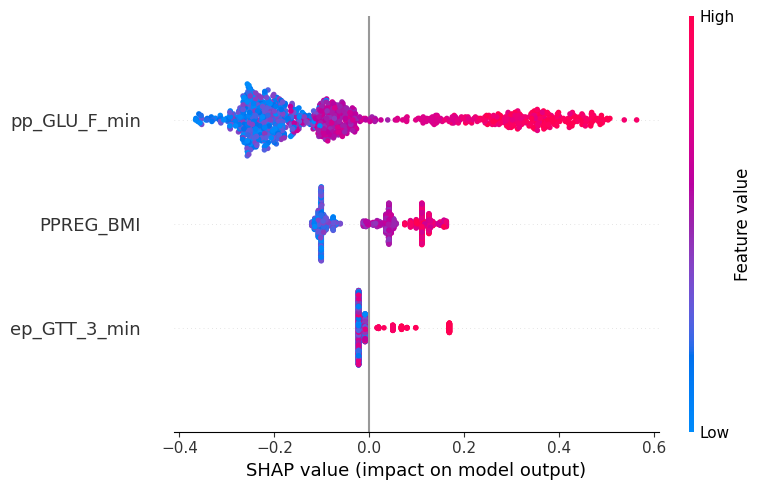

In [51]:
shap.summary_plot(shap_values, temp, max_display = 3, plot_size=(8, 5))

[0.         0.09090909 0.11363636 0.13636364 0.15909091 0.22727273
 0.22727273 0.22727273 0.27272727 0.27272727 0.27272727 0.29545455
 0.29545455 0.31818182 0.34090909 0.36363636 0.36937557 0.47727273
 0.47727273 0.5        0.5        0.5        0.5        0.54545455
 0.54545455 0.54545455 0.54545455 0.54545455 0.54545455 0.54545455
 0.56818182 0.56818182 0.58715947 0.59090909 0.61363636 0.63636364
 0.63636364 0.63636364 0.70454545 0.70454545 0.74627589 0.75
 0.75       0.75       0.75       0.75       0.75       0.77923171
 0.79545455 0.79545455 0.79545455 0.79545455 0.79545455 0.79545455
 0.81818182 0.84090909 0.86099633 0.86363636 0.86363636 0.86363636
 0.86363636 0.86363636 0.86363636 0.86363636 0.90909091 0.90909091
 0.90909091 0.90909091 0.90909091 0.90909091 0.90909091 0.90909091
 0.93543388 0.95454545 0.95454545 0.95454545 0.95454545 0.95454545
 0.95454545 0.95454545 0.95454545 0.95454545 0.95454545 0.95454545
 0.95454545 0.97727273 0.97727273 0.97727273 0.97727273 0.97727273
 

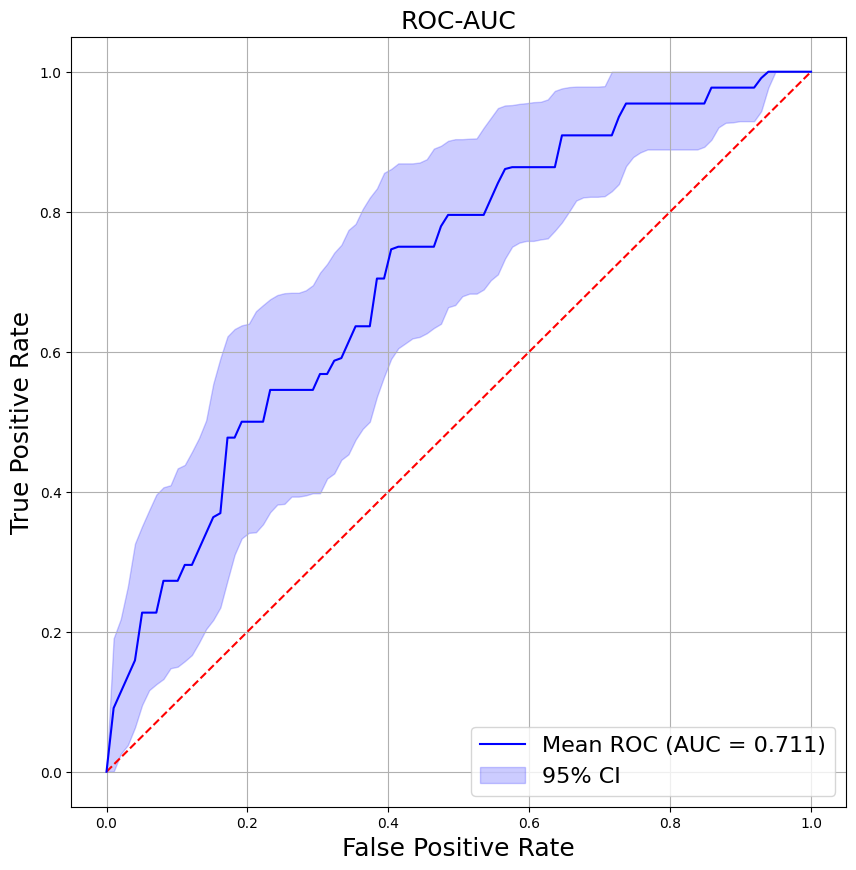

[0.         0.04444444 0.08888889 0.14393939 0.16919192 0.1969697
 0.22727273 0.25185185 0.25925926 0.28571429 0.28218695 0.27865961
 0.16635041 0.1730972  0.17037037 0.16825397 0.16990211 0.16658371
 0.16326531 0.16913432 0.17500333 0.15757871 0.13691442 0.12703252
 0.13109756 0.13530545 0.13994188 0.12121212 0.11283438 0.10445664
 0.10290647 0.10144844 0.10125196 0.10375587 0.09994297 0.09703031
 0.09876543 0.09829242 0.0978194  0.09960151 0.10138232 0.10281639
 0.10505935 0.10729605 0.10951395 0.11173184 0.1139251  0.11611835
 0.10450284 0.09569182 0.10392532 0.09818374 0.09492974 0.09604786
 0.08571429 0.08255965 0.07940501 0.07645221 0.07707137 0.07513123
 0.07553778 0.07622367 0.076893   0.07235142 0.07323686 0.07412229
 0.07500773 0.07589316 0.07661783 0.07679226 0.07683483 0.07724344
 0.07765205 0.07806066 0.07846928 0.06882039 0.06948359 0.07018886
 0.07064889 0.06431788 0.06470867 0.06486486 0.06483541 0.06480596
 0.06318853 0.06027853 0.06100358 0.06043011 0.05994485 0.06009

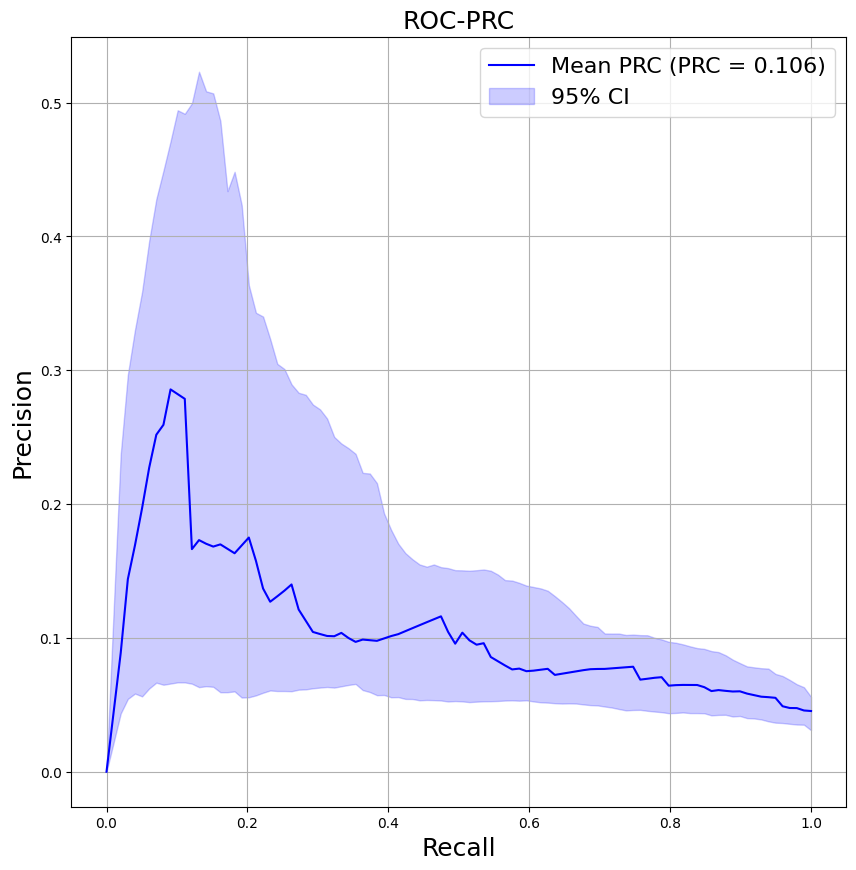

In [52]:
#ROC Plots 

overall_fpr = prob_metrics_1['FPRs']
overall_tpr = prob_metrics_1['TPRs']
overall_precision = prob_metrics_1['Precision']
overall_recall = prob_metrics_1['Recall']

#interpolate to make consistent across bootstrapps
mean_fpr = np.linspace(0, 1, 100)

mean_tpr = np.interp(mean_fpr, overall_fpr, overall_tpr)

boot_tprs_interp = []
for fpr, tpr in zip(boot_fprs, boot_tprs):
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    boot_tprs_interp.append(interp_tpr)

boot_tprs_interp = np.array(boot_tprs_interp)

#calculate avg and 95% CIs
ci_tpr_lower = np.percentile(boot_tprs_interp, 2.5, axis=0)
ci_tpr_upper = np.percentile(boot_tprs_interp, 97.5, axis=0)

print(mean_tpr)
print(ci_tpr_lower)
print(ci_tpr_upper)

#plot
plt.figure(figsize=(10, 10))
plt.plot(mean_fpr, mean_fpr, '--', color='red')
plt.plot(mean_fpr, mean_tpr, label=f"Mean ROC (AUC = {auc(mean_fpr, mean_tpr):.3f})", color='blue')
plt.fill_between(mean_fpr, ci_tpr_lower, ci_tpr_upper, color='blue', alpha=0.2, label="95% CI")
plt.xlabel("False Positive Rate", fontsize=18)
plt.ylabel("True Positive Rate", fontsize=18)
plt.title("ROC-AUC", fontsize=18)
plt.legend(loc = 'lower right', fontsize=16)
plt.grid()
plt.show()


##Repeat for PRC curve
mean_recall = np.linspace(0, 1, 100)

sorted_indices = np.argsort(overall_recall)
recall2 = overall_recall[sorted_indices]
precision2 = overall_precision[sorted_indices]
overall_precision_interp = np.interp(mean_recall, recall2, precision2)

boot_precisions_interp = []
for recall, precision in zip(boot_recalls, boot_precisions):
    sorted_indices = np.argsort(recall)
    recall = recall[sorted_indices]
    precision = precision[sorted_indices]
    interp_precision = np.interp(mean_recall, recall, precision)
    boot_precisions_interp.append(interp_precision)

boot_precisions_interp = np.array(boot_precisions_interp)


ci_lower = np.percentile(boot_precisions_interp, 2.5, axis=0)
ci_upper = np.percentile(boot_precisions_interp, 97.5, axis=0)

print(overall_precision_interp)
print(ci_lower)
print(ci_upper)

plt.figure(figsize=(10, 10))
plt.plot(mean_recall, overall_precision_interp, label=f"Mean PRC (PRC = {prob_metrics_1['AUPRC']:.3f})", color='blue')
plt.fill_between(mean_recall, ci_lower, ci_upper, color='blue', alpha=0.2, label="95% CI")
plt.xlabel("Recall", fontsize=18)
plt.ylabel("Precision", fontsize=18)
plt.title("ROC-PRC", fontsize=18)
plt.legend(loc = 'upper right', fontsize=16)
plt.grid()
plt.show()